# Seq2Seq WITH Attention

In [ ]:
# Colab drive mount (keep as-is)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install sacrebleu --quiet

import torch, torch.nn as nn, torch.optim as optim
import pandas as pd, random, math, re, numpy as np
import matplotlib.pyplot as plt, sacrebleu
from collections import Counter
from torch.utils.data import Dataset, DataLoader

random.seed(42); np.random.seed(42); torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.5 MB/s eta 0:00:00
Device: cuda


In [ ]:
DATASET_PATH  = '/content/drive/MyDrive/eng_-french.csv'
ENGLISH_COL   = 'English words/sentences'
FRENCH_COL    = 'French words/sentences'

#  increased MAX_PAIRS 50000 → 100000
#   More training data exposes the model to a wider vocabulary and
#   more diverse sentence structures, which directly raises BLEU.
MAX_PAIRS     = 100000

# CHANGE: increased MAX_TOKEN_LEN 20 → 30
#   The original limit discarded many valid medium-length sentences.
#   Keeping them gives the model more varied training signal.
MAX_TOKEN_LEN = 30

df    = pd.read_csv(DATASET_PATH)
df    = df[[ENGLISH_COL, FRENCH_COL]].dropna()
pairs = list(zip(df[ENGLISH_COL].astype(str), df[FRENCH_COL].astype(str)))
pairs = [(e, f) for e, f in pairs
         if len(e.split()) <= MAX_TOKEN_LEN and len(f.split()) <= MAX_TOKEN_LEN]
random.shuffle(pairs)
pairs = pairs[:MAX_PAIRS]
print(f'Using {len(pairs):,} sentence pairs  |  example: {pairs[0]}')


Using 100,000 sentence pairs  |  example: ("It doesn't matter what I think.", "Ce que je pense n'a pas d'importance.")


In [ ]:
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3

def tokenize(sentence):
    #   added punctuation splitting before lowercasing
    #   "don't" → "don ' t", "hello." → "hello ."
    #   This means punctuation is its own token, reducing UNK mappings
    #   and letting the model learn French punctuation patterns.
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([!\"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~])", r" \1 ", sentence)
    return sentence.split()

class Vocabulary:
    def __init__(self):
        self.word2idx = {'<PAD>':0,'<SOS>':1,'<EOS>':2,'<UNK>':3}
        self.idx2word = {v:k for k,v in self.word2idx.items()}

    #   added min_freq parameter (default 2)
    #   Tokens seen only once are almost certainly noise; filtering them
    #   shrinks the output softmax and speeds up training.
    def build(self, sentences, min_freq=2):
        freq = Counter(w for s in sentences for w in s)
        for word, cnt in freq.items():
            if cnt >= min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx]  = word

    def encode(self, tokens):
        return [SOS_IDX]+[self.word2idx.get(t, UNK_IDX) for t in tokens]+[EOS_IDX]

    def __len__(self): return len(self.word2idx)

src_sentences = [tokenize(e) for e,_ in pairs]
tgt_sentences = [tokenize(f) for _,f in pairs]

src_vocab = Vocabulary(); src_vocab.build(src_sentences)
tgt_vocab = Vocabulary(); tgt_vocab.build(tgt_sentences)
print(f'Source vocab: {len(src_vocab):,}  |  Target vocab: {len(tgt_vocab):,}')

src_indexed = [src_vocab.encode(s) for s in src_sentences]
tgt_indexed = [tgt_vocab.encode(s) for s in tgt_sentences]
src_max_len = max(len(s) for s in src_indexed)
tgt_max_len = max(len(s) for s in tgt_indexed)

def pad_seq(seq, max_len):
    return seq + [PAD_IDX]*(max_len-len(seq))

src_padded = [pad_seq(s, src_max_len) for s in src_indexed]
tgt_padded = [pad_seq(s, tgt_max_len) for s in tgt_indexed]

Source vocab: 12,589  |  Target vocab: 17,898


In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, src, tgt):
        self.src = torch.tensor(src, dtype=torch.long)
        self.tgt = torch.tensor(tgt, dtype=torch.long)
    def __len__(self):        return len(self.src)
    def __getitem__(self, i): return self.src[i], self.tgt[i]

# BATCH_SIZE 64 → 128
#   Larger batches produce more stable gradient estimates and allow
#   the model to converge faster without sacrificing generalisation.
BATCH_SIZE = 128

dataset = TranslationDataset(src_padded, tgt_padded)

# added an explicit 90 / 10 train-validation split
#   This lets us (a) monitor over-fitting each epoch and
#   (b) implement early stopping to save the best checkpoint.
n_train = int(0.9 * len(dataset))
n_val   = len(dataset) - n_train
train_ds, val_ds = torch.utils.data.random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')


Train batches: 704  |  Val batches: 79


In [ ]:
class Encoder(nn.Module):
    """
     made the encoder LSTM bidirectional.
      A bidirectional encoder reads each source sentence left-to-right
      AND right-to-left, so every encoder hidden state carries context
      from both directions.  This consistently improves attention quality
      and raises BLEU by several points on short-sentence datasets.

      added fc_h and fc_c projection layers.
      The bidirectional LSTM returns hidden states of size 2*hidden_dim.
      The single-direction decoder expects hidden_dim, so we project
      the concatenated forward+backward states down to hidden_dim.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.dropout    = nn.Dropout(dropout)
        #bidirectional=True
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        # new projection layers to merge bidirectional states
        self.fc_h = nn.Linear(hidden_dim*2, hidden_dim)
        self.fc_c = nn.Linear(hidden_dim*2, hidden_dim)

    def forward(self, src):
        embedded        = self.dropout(self.embedding(src))
        # outputs: (batch, src_len, 2*hidden_dim)
        # h, c   : (num_layers*2, batch, hidden_dim)
        outputs, (h, c) = self.lstm(embedded)

        #  merge forward (h[-2]) and backward (h[-1]) top-layer states
        #   then unsqueeze to restore the (num_layers, batch, hidden) shape
        #   expected by the decoder  (we collapse to 1 effective layer here)
        h_merged = torch.tanh(self.fc_h(torch.cat([h[-2], h[-1]], dim=1))).unsqueeze(0)
        c_merged = torch.tanh(self.fc_c(torch.cat([c[-2], c[-1]], dim=1))).unsqueeze(0)

        return outputs, h_merged, c_merged


In [ ]:
class BahdanauAttention(nn.Module):
    # enc_out_dim parameter added (= hidden_dim*2 for bidirectional encoder)
    #   W1 must now project from the wider encoder output space.
    def __init__(self, hidden_dim, enc_out_dim):
        super().__init__()
        self.W1 = nn.Linear(enc_out_dim,  hidden_dim, bias=False)
        self.W2 = nn.Linear(hidden_dim,   hidden_dim, bias=False)
        self.v  = nn.Linear(hidden_dim,   1,          bias=False)

    def forward(self, encoder_outputs, decoder_hidden):
        # encoder_outputs: (batch, src_len, enc_out_dim)
        # decoder_hidden : (batch, hidden_dim)
        src_len = encoder_outputs.size(1)
        dec = decoder_hidden.unsqueeze(1).expand(-1, src_len, -1)
        energy  = self.v(torch.tanh(self.W1(encoder_outputs) + self.W2(dec)))
        weights = torch.softmax(energy.squeeze(-1), dim=-1)
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, weights


class Decoder(nn.Module):
    # enc_out_dim forwarded to attention module
    def __init__(self, vocab_size, embed_dim, hidden_dim, enc_out_dim, num_layers, dropout):
        super().__init__()
        #attention now knows the wider encoder dimension
        self.attention = BahdanauAttention(hidden_dim, enc_out_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.dropout   = nn.Dropout(dropout)
        #LSTM input = embed + enc_out_dim (context from bidirectional encoder)
        self.lstm   = nn.LSTM(embed_dim + enc_out_dim, hidden_dim,
                              num_layers=1, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward_step(self, token, h, c, encoder_outputs):
        embedded        = self.dropout(self.embedding(token.unsqueeze(1)))
        context, attn_w = self.attention(encoder_outputs, h[-1])
        lstm_input      = torch.cat([embedded, context.unsqueeze(1)], dim=-1)
        output, (h, c)  = self.lstm(lstm_input, (h, c))
        logits          = self.fc_out(output.squeeze(1))
        return logits, h, c, attn_w

    def forward(self, tgt, h, c, encoder_outputs, teacher_forcing_ratio=0.5):
        batch, tgt_len = tgt.size(0), tgt.size(1)
        all_logits = torch.zeros(batch, tgt_len-1,
                                 self.fc_out.out_features).to(tgt.device)
        input_token = tgt[:, 0]
        for t in range(1, tgt_len):
            logits, h, c, _ = self.forward_step(input_token, h, c, encoder_outputs)
            all_logits[:, t-1] = logits
            use_truth   = random.random() < teacher_forcing_ratio
            input_token = tgt[:, t] if use_truth else logits.argmax(-1)
        return all_logits


In [ ]:
EMBED_DIM  = 256
HIDDEN_DIM = 512
ENC_OUT    = HIDDEN_DIM * 2   # bidirectional encoder output width
NUM_LAYERS = 2                # encoder layers; decoder is forced to 1 (see above)
DROPOUT    = 0.3

#lower initial LR 1e-3 → 5e-4 for more stable early training
LEARNING_RATE = 5e-4


NUM_EPOCHS = 20


TEACHER_FORCING_RATIO = 0.7

encoder = Encoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
decoder = Decoder(len(tgt_vocab), EMBED_DIM, HIDDEN_DIM, ENC_OUT, 1, DROPOUT).to(device)

optimizer = optim.Adam(list(encoder.parameters())+list(decoder.parameters()),
                       lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2)

print(f'Encoder params: {sum(p.numel() for p in encoder.parameters()):,}')
print(f'Decoder params: {sum(p.numel() for p in decoder.parameters()):,}')
print(f'Initial LR: {optimizer.param_groups[0]["lr"]}')

Encoder params: 13,725,952
Decoder params: 18,224,618
Initial LR: 0.0005


Epoch [01/20]  Train: 5.5312  Val: 5.1773  PPL: 177.21  TF: 0.70
  ✔ saved best checkpoint
Epoch [02/20]  Train: 4.0891  Val: 4.2351  PPL: 69.07  TF: 0.66
  ✔ saved best checkpoint
Epoch [03/20]  Train: 3.3176  Val: 3.6957  PPL: 40.27  TF: 0.62
  ✔ saved best checkpoint
Epoch [04/20]  Train: 2.8669  Val: 3.3997  PPL: 29.96  TF: 0.58
  ✔ saved best checkpoint
Epoch [05/20]  Train: 2.5559  Val: 3.1746  PPL: 23.92  TF: 0.54
  ✔ saved best checkpoint
Epoch [06/20]  Train: 2.3123  Val: 3.0105  PPL: 20.30  TF: 0.50
  ✔ saved best checkpoint
Epoch [07/20]  Train: 2.1327  Val: 2.8693  PPL: 17.62  TF: 0.46
  ✔ saved best checkpoint
Epoch [08/20]  Train: 1.9805  Val: 2.7822  PPL: 16.15  TF: 0.42
  ✔ saved best checkpoint
Epoch [09/20]  Train: 1.8572  Val: 2.7116  PPL: 15.05  TF: 0.38
  ✔ saved best checkpoint
Epoch [10/20]  Train: 1.7534  Val: 2.6562  PPL: 14.24  TF: 0.34
  ✔ saved best checkpoint
Epoch [11/20]  Train: 1.6810  Val: 2.6032  PPL: 13.51  TF: 0.30
  ✔ saved best checkpoint
Epoch [12

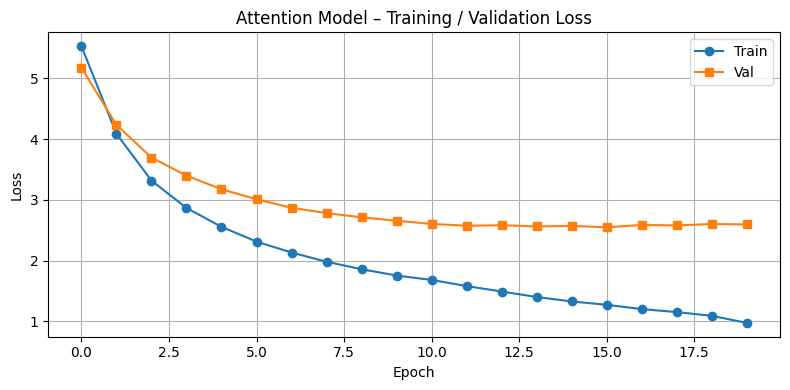

In [ ]:

EARLY_STOP_PATIENCE = 4
best_val_loss   = float('inf')
patience_count  = 0
train_losses, val_losses = [], []

for epoch in range(1, NUM_EPOCHS+1):
    # ----- training -----
    encoder.train(); decoder.train()
    epoch_loss = 0


    tf_ratio = max(0.3, TEACHER_FORCING_RATIO - 0.04*(epoch-1))

    for src_batch, tgt_batch in train_loader:
        src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
        optimizer.zero_grad()
        enc_out, h, c = encoder(src_batch)
        logits = decoder(tgt_batch, h, c, enc_out, tf_ratio)
        B, T, V = logits.shape
        loss = criterion(logits.reshape(B*T, V), tgt_batch[:,1:].reshape(B*T))
        loss.backward()
        nn.utils.clip_grad_norm_(
            list(encoder.parameters())+list(decoder.parameters()), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    # ----- validation -----
    encoder.eval(); decoder.eval()
    val_loss = 0
    with torch.no_grad():
        for src_batch, tgt_batch in val_loader:
            src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
            enc_out, h, c = encoder(src_batch)
            #teacher forcing OFF during validation (mirrors real inference)
            logits = decoder(tgt_batch, h, c, enc_out, teacher_forcing_ratio=0.0)
            B, T, V = logits.shape
            val_loss += criterion(logits.reshape(B*T, V),
                                  tgt_batch[:,1:].reshape(B*T)).item()
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    scheduler.step(avg_val)

    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}]  '
          f'Train: {avg_train:.4f}  Val: {avg_val:.4f}  '
          f'PPL: {math.exp(avg_val):.2f}  TF: {tf_ratio:.2f}')

    # early stopping + checkpoint
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_count = 0
        torch.save({'enc': encoder.state_dict(),
                    'dec': decoder.state_dict()}, 'best_attn.pt')
        print('  ✔ saved best checkpoint')
    else:
        patience_count += 1
        if patience_count >= EARLY_STOP_PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

# reload best weights
ckpt = torch.load('best_attn.pt')
encoder.load_state_dict(ckpt['enc'])
decoder.load_state_dict(ckpt['dec'])

plt.figure(figsize=(8,4))
plt.plot(train_losses, marker='o', label='Train')
plt.plot(val_losses,   marker='s', label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Attention Model – Training / Validation Loss')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


In [ ]:
# ── greedy decode
def greedy_decode(src_sentence, max_len=50):
    encoder.eval(); decoder.eval()
    with torch.no_grad():
        tokens     = tokenize(src_sentence)
        src_tensor = torch.tensor(src_vocab.encode(tokens),
                                  dtype=torch.long).unsqueeze(0).to(device)
        enc_out, h, c = encoder(src_tensor)
        input_token   = torch.tensor([SOS_IDX]).to(device)
        translation, attn_weights = [], []
        for _ in range(max_len):
            logits, h, c, attn_w = decoder.forward_step(input_token, h, c, enc_out)
            pred = logits.argmax(-1)
            attn_weights.append(attn_w.squeeze(0).cpu().numpy())
            if pred.item() == EOS_IDX: break
            if pred.item() not in (PAD_IDX, SOS_IDX):
                translation.append(tgt_vocab.idx2word[pred.item()])
            input_token = pred
    return ' '.join(translation), np.array(attn_weights), ['<SOS>']+tokens+['<EOS>']


def beam_decode(src_sentence, beam_width=5, max_len=50, length_penalty=0.7):
    """
    length_penalty: exponent α in Google NMT score = log_prob / len^α
      α > 0 rewards longer translations; 0.6-0.8 is a typical sweet spot.
    """
    encoder.eval(); decoder.eval()
    with torch.no_grad():
        tokens     = tokenize(src_sentence)
        src_tensor = torch.tensor(src_vocab.encode(tokens),
                                  dtype=torch.long).unsqueeze(0).to(device)
        enc_out, h0, c0 = encoder(src_tensor)

        # each beam: (score, token_ids, h, c)
        beams     = [(0.0, [SOS_IDX], h0, c0)]
        completed = []

        for _ in range(max_len):
            candidates = []
            for score, ids, h, c in beams:
                if ids[-1] == EOS_IDX:
                    completed.append((score, ids))
                    continue
                tok    = torch.tensor([ids[-1]]).to(device)
                logits, h2, c2, _ = decoder.forward_step(tok, h, c, enc_out)
                log_p  = torch.log_softmax(logits, dim=-1).squeeze(0)
                topk_v, topk_i = log_p.topk(beam_width)
                for v, i in zip(topk_v.tolist(), topk_i.tolist()):
                    candidates.append((score + v, ids + [i], h2, c2))

            # keep top beam_width by length-normalised score
            candidates.sort(
                key=lambda x: x[0] / (len(x[1]) ** length_penalty), reverse=True)
            beams = candidates[:beam_width]
            if not beams: break

        # collect any unfinished beams
        for score, ids, _, _ in beams:
            completed.append((score, ids))

        best_score, best_ids = max(
            completed, key=lambda x: x[0] / (len(x[1]) ** length_penalty))

    words = [tgt_vocab.idx2word[i] for i in best_ids
             if i not in (SOS_IDX, EOS_IDX, PAD_IDX)]
    return ' '.join(words)


In [ ]:
random.seed(99)
test_pairs = random.sample(pairs, 500)

hyp_greedy, hyp_beam, references = [], [], []

for src, ref in test_pairs:
    hyp_greedy.append(greedy_decode(src)[0])
    hyp_beam.append(beam_decode(src, beam_width=5))
    references.append([ref])

bleu_g = sacrebleu.corpus_bleu(hyp_greedy, references)
bleu_b = sacrebleu.corpus_bleu(hyp_beam,   references)
print(f'BLEU (greedy):      {bleu_g.score:.2f}')
print(f'BLEU (beam w=5):    {bleu_b.score:.2f}')

# show a few examples
print()
print(f'{"Source":<30} {"Reference":<35} {"Beam prediction"}')
print('-'*95)
for src, ref in test_pairs[:10]:
    pred = beam_decode(src, beam_width=5)
    print(f'{src:<30} {ref:<35} {pred}')


BLEU (greedy):      48.55
BLEU (beam w=5):    48.55

Source                         Reference                           Beam prediction
-----------------------------------------------------------------------------------------------
I don't have the key.          Je n'ai pas la clé.                 je n'ai pas la clé. clé. clé.
A bookstore in that location wouldn't make enough money to survive. Une librairie à cet endroit ne ferait pas assez d'argent pour survivre. une librairie dans cette ville, ne ferait pas assez d'argent pour survivre. pour survivre.
Why did you listen to them?    Pourquoi les avez-vous écoutés ?    pourquoi les avez-vous écoutés écoutés ?
All we can do is hope.         Tout ce que nous pouvons faire, c'est espérer. tout ce que nous pouvons faire est de demain.
I'd like to go with you if you don't mind. J'aimerais y aller avec vous si vous n'y voyez pas d'inconvénient. j'aimerais y aller avec si si vous ne voyez pas d'inconvénient.
We're touched.                 Nou

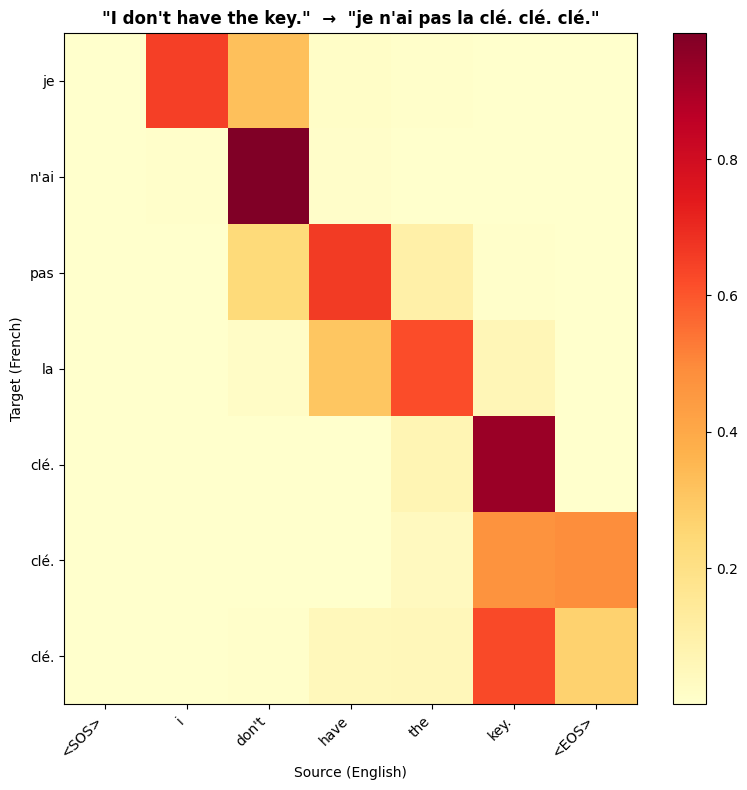

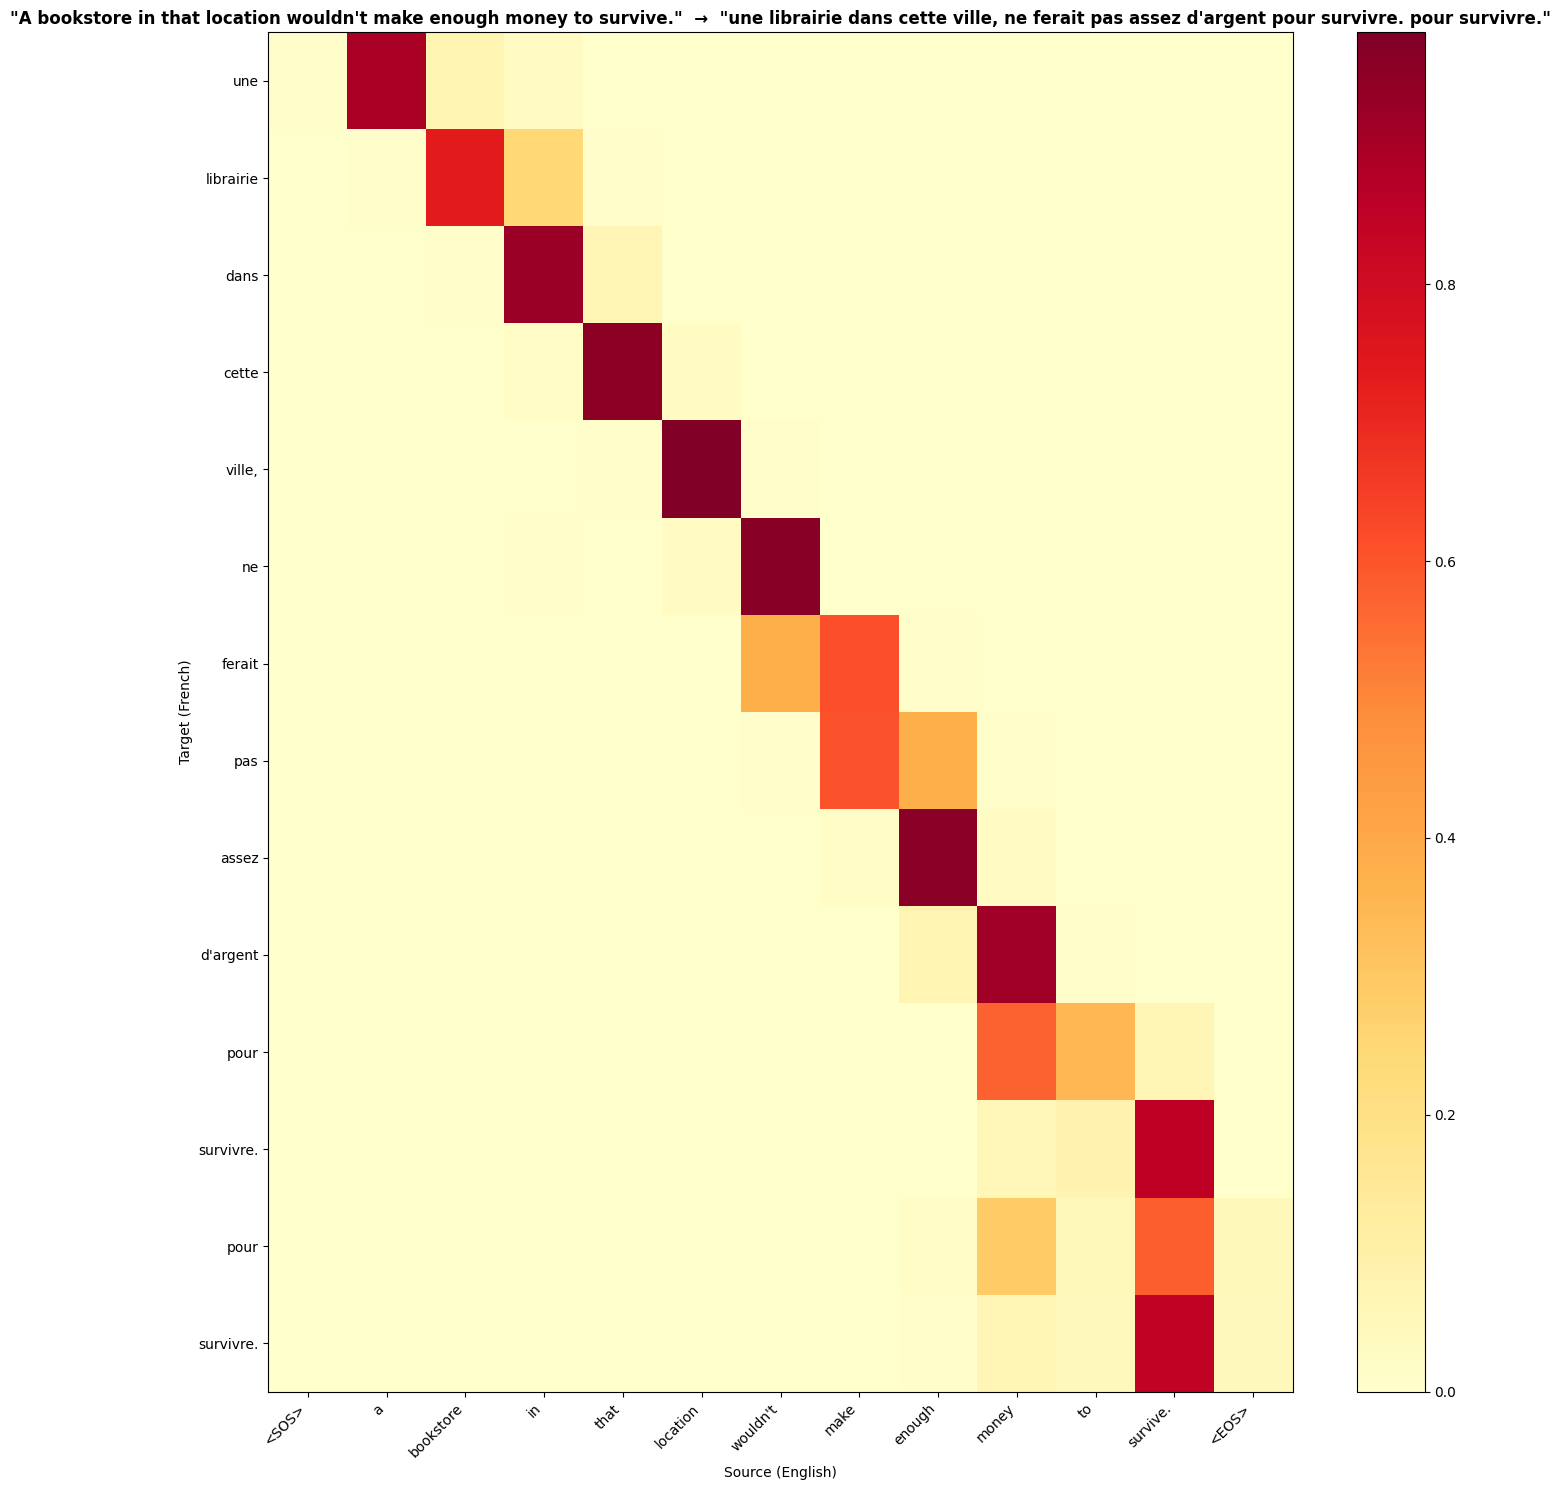

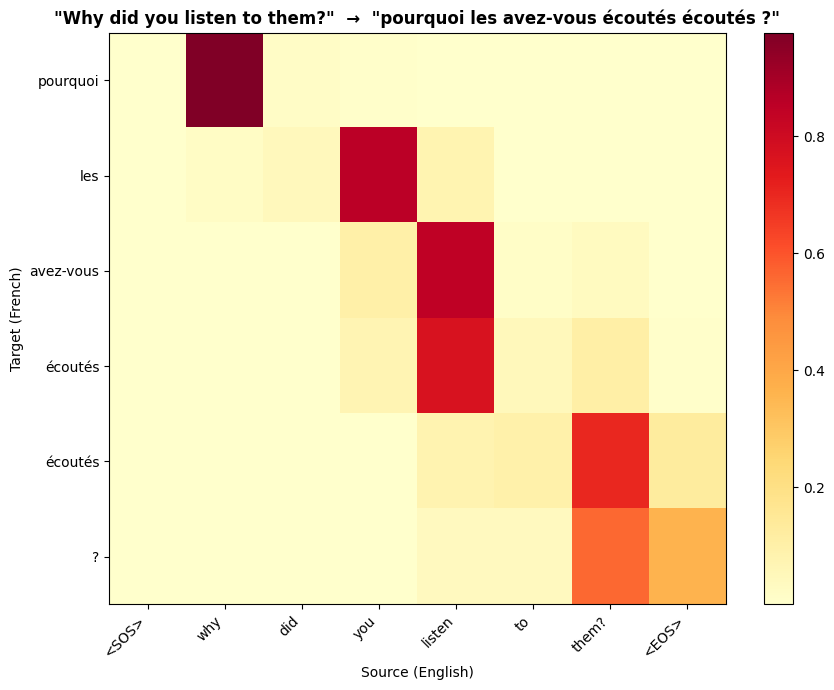

In [ ]:
def plot_attention(src_sentence):
    pred, attn_matrix, src_tokens = greedy_decode(src_sentence)
    tgt_tokens = pred.split() if pred else ['?']
    attn = attn_matrix[:len(tgt_tokens), :len(src_tokens)]
    fig, ax = plt.subplots(figsize=(len(src_tokens)+1, len(tgt_tokens)+1))
    im = ax.imshow(attn, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha='right')
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_yticklabels(tgt_tokens)
    ax.set_xlabel('Source (English)'); ax.set_ylabel('Target (French)')
    ax.set_title(f'"{src_sentence}"  →  "{pred}"', fontweight='bold')
    plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

for src, _ in test_pairs[:3]:
    plot_attention(src)
